In [1]:
import scipy.io
from scipy.signal import argrelextrema
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd

In [2]:
mat = scipy.io.loadmat('Inorfull.mat')

In [3]:
Sample_Concentrations = mat['CONC']
Sample_absorbance     = mat['DATA']

wavelengths           = mat['WAV'][0]

Pure_Co_absorbance    = mat['PureCo'][0]
Pure_Co_concentration = mat['PureCoCONC'][0]

Pure_Cr_absorbance    = mat['PureCr'][0]
Pure_Cr_concentration = mat['PureCrCONC'][0]

Pure_Ni_absorbance    = mat['PureNi'][0]
Pure_Ni_concentration = mat['PureNiCONC'][0]


In [4]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


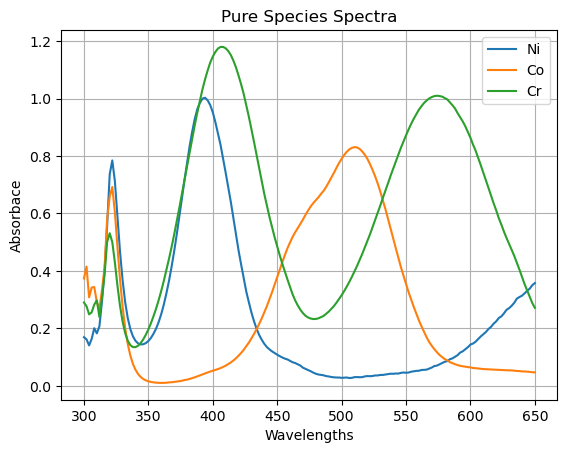

In [34]:
# plt.style.use('seaborn-v0_8-pastel')
plt.plot(wavelengths.T, Pure_Ni_absorbance.T)
plt.plot(wavelengths.T, Pure_Co_absorbance.T)
plt.plot(wavelengths.T, Pure_Cr_absorbance.T)
plt.title('Pure Species Spectra')
plt.xlabel('Wavelengths')
plt.ylabel('Absorbace')
plt.legend(['Ni', 'Co', 'Cr'])
plt.grid()

In [6]:
np.shape(mat['stdDATA'])

(130, 176)

### PART A : 
---
* Using the pure component spectra, identify the wavelengths at which the pure species have maximum absorbance. 
* Denote them as λmax values and report them. 
* Build a calibration model using OLS by selecting the mixture absorbances at the λmax wavelengths. 
* Report the RMSE obtained using LOOCV.

In [7]:
max_Co = np.where( Pure_Co_absorbance == Pure_Co_absorbance.max())
max_Cr = np.where( Pure_Cr_absorbance == Pure_Cr_absorbance.max())
max_Ni = np.where( Pure_Ni_absorbance == Pure_Ni_absorbance.max())

print("Max Wavelengths and its corresponding absorbance of Pure Compounds:")
print("-------------------------------------------------------------------")
print('Wavelength :', wavelengths[max_Co] [0],', Absorbance :', Pure_Co_absorbance[max_Co] [0])
print('Wavelength :', wavelengths[max_Cr] [0],', Absorbance :', Pure_Cr_absorbance[max_Cr] [0])
print('Wavelength :', wavelengths[max_Ni] [0],', Absorbance :', Pure_Ni_absorbance[max_Ni] [0])

# wavelengths[0]

Max Wavelengths and its corresponding absorbance of Pure Compounds:
-------------------------------------------------------------------
Wavelength : 510 , Absorbance : 0.8309784
Wavelength : 406 , Absorbance : 1.1796060000000002
Wavelength : 394 , Absorbance : 1.0027466666666667


In [8]:
A = Sample_absorbance[:, [max_Co, max_Cr, max_Ni]].T[0,0].T[0::5]
C = Sample_Concentrations[0::5]

$$ C_{N \times p} = A_{N \times p} \hspace{4pt} B_{p\times p} $$
$$ B = \left( A^{T}A\right)^{-1}A^{T}C $$
* $C$ is the Concentration Matrix
* $A$ is the Absorbance Matrix
* $B$ is the Callibration Matrix
* Here the data is not mean shifted as we are trying to fit a curve of the form $\hspace{5pt}C=AB$

In [9]:
def OLS_regression(x, y) : 
    return np.linalg.inv(x.T@x) @ (x.T@y)

In [10]:
N = 26
p = 3 

In [11]:
RMSE = 0
# LOOCV algorithm 
for i in range(26) : 
    x = np.append(A[:i], A[i+1:], axis=0)
    y = np.append(C[:i], C[i+1:], axis=0)
    b = OLS_regression(x, y)

    error = C[i] - A[i]@b
    # RMSE Calculated for every iteration of LOOCV and summed up 
    RMSE = RMSE + error@error.T

# RMSE computation from SSE
RMSE = (RMSE/N)**0.5

In [12]:
RMSE

0.0025980526083163057

* **Second case because the peak absorbance wavelengths of Chromium and Nickel are very close to each other ( 406 and 394 nm)**
* **Chromium has two peaks in its spectroscopy graph so there is the possibility of considering this other peak that does not interfere with the peaks of the remaining species**

In [13]:
max_Cr = 137

print("Case 2 :")
print("-------------------------------------------------------------------")
print('Wavelength :', wavelengths[max_Co] [0],', Absorbance :', Pure_Co_absorbance[max_Co] [0])
print('Wavelength :', wavelengths[max_Cr],', Absorbance :', Pure_Cr_absorbance[max_Cr])
print('Wavelength :', wavelengths[max_Ni] [0],', Absorbance :', Pure_Ni_absorbance[max_Ni] [0])

Case 2 :
-------------------------------------------------------------------
Wavelength : 510 , Absorbance : 0.8309784
Wavelength : 574 , Absorbance : 1.0097349999999998
Wavelength : 394 , Absorbance : 1.0027466666666667


In [14]:
max_Ni

(array([47]),)

In [15]:
argrelextrema(Pure_Cr_absorbance, np.greater)
# to find all the local minima in the spectroscopy graph

(array([  5,  10,  53, 137]),)

In [16]:
A = Sample_absorbance[:, [105, 137, 47]][0::5]
C = Sample_Concentrations[0::5]

In [17]:
RMSE = 0
# LOOCV algorithm 
for i in range(26) : 
    x = np.append(A[:i], A[i+1:], axis=0)
    y = np.append(C[:i], C[i+1:], axis=0)
    b = OLS_regression(x, y)

    error = C[i] - A[i]@b
    # RMSE Calculated for every iteration of LOOCV and summed up 
    RMSE = RMSE + error@error.T

# RMSE computation from SSE
RMSE = (RMSE/N)**0.5

In [18]:
RMSE

0.0008110347166935078

---
### Part B : Principal Component Regression

* Case 1 : where the data matrix is comprising of the first sample of for the 26 mixtures

In [19]:
A = Sample_absorbance[0::5]
C  = Sample_Concentrations[0::5] 

As = A - A.mean(axis=0)

In [20]:
rmse = []
for j in range(1,6) :
    RMSE = 0 
    for i in range(26) : 

        # LOOCV
        x = np.append(A[:i], A[i+1:], axis=0)   # modified Absorbance Matrix
        y = np.append(C[:i], C[i+1:], axis=0)   # modified Concentration Matrix 
        
        # Mean Shifting the data to perpare for PCA
        xs = x - x.mean(axis=0)
        ys = y - y.mean(axis=0)

        # Performing SVD of Mean shifted Asborbance matrix : xs
        u, s, v = svd(xs/(N-1)**0.5, full_matrices=False)
        
        # Choosing the number of eigenvectors for Computing scores
        Nv = j 
        scores = xs@(v.T[:,0:Nv])
        B      = OLS_regression(scores, ys) # Computing regression Parameters Using OLS from mean shifted data

        # Error and RMSE Computation
        error = (A[i]-x.mean(axis=0))@(v.T[:,0:Nv])@B + y.mean(axis=0) - C[i]
        RMSE += error@error.T

    RMSE = (RMSE/N)**0.5
    rmse.append(RMSE)

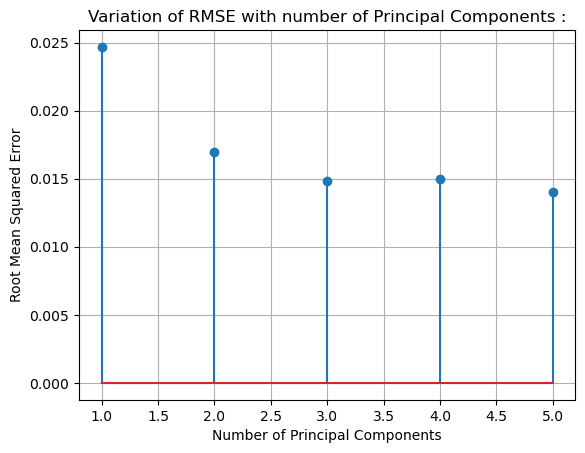

In [21]:
plt.stem([1,2,3,4,5], rmse)
plt.title("Variation of RMSE with number of Principal Components :")
plt.xlabel('Number of Principal Components')
plt.ylabel('Root Mean Squared Error')
plt.grid()

* Case 2 : where the data matrix the mean of the 5 Absorbances measured for each mixtures 

In [22]:
Am = np.zeros((1,176))

for i in range(0,130,5) : 
    Am = np.append(Am, np.reshape(Sample_absorbance[i:i+5].mean(axis=0), (1,176)), axis=0)

In [23]:
Am = np.delete(Am, 0, axis=0)

In [24]:
rmse = []
for j in range(1,6) :
    RMSE = 0 
    for i in range(26) : 

        # LOOCV
        x = np.append(Am[:i], Am[i+1:], axis=0)   # modified Absorbance Matrix
        y = np.append(C[:i], C[i+1:], axis=0)   # modified Concentration Matrix 
        
        # Mean Shifting the data to perpare for PCA
        xs = x - x.mean(axis=0)
        ys = y - y.mean(axis=0)

        # Performing SVD of Mean shifted Asborbance matrix : xs
        u, s, v = svd(xs/(N-1)**0.5, full_matrices=False)
        
        # Choosing the number of eigenvectors for Computing scores
        Nv = j 
        scores = xs@(v.T[:,0:Nv])
        B      = OLS_regression(scores, ys) # Computing regression Parameters Using OLS from mean shifted data

        # Error and RMSE Computation
        error = (Am[i]-x.mean(axis=0))@(v.T[:,0:Nv])@B + y.mean(axis=0) - C[i]
        RMSE += error@error.T

    RMSE = (RMSE/N)**0.5
    rmse.append(RMSE)

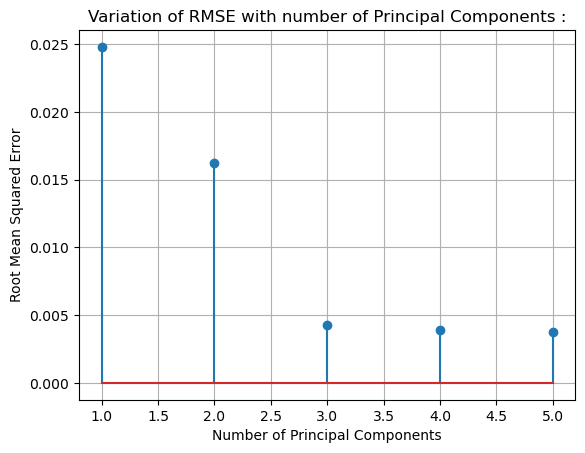

In [25]:
plt.stem([1,2,3,4,5], rmse)
plt.title("Variation of RMSE with number of Principal Components :")
plt.xlabel('Number of Principal Components')
plt.ylabel('Root Mean Squared Error')
plt.grid()

---
### Part C : Scaling the data matrix with the standard deviation before PCA

In [26]:
A_scaled = np.zeros((1,176))

for i in range(0,130,5) : 
    A_scaled = np.append(A_scaled, np.reshape(Sample_absorbance[i:i+5].std(axis=0), (1,176)), axis=0)

A_scaled = np.delete(A_scaled, 0, axis=0)

In [27]:
xaxhs = [ i for i in range(176) ]

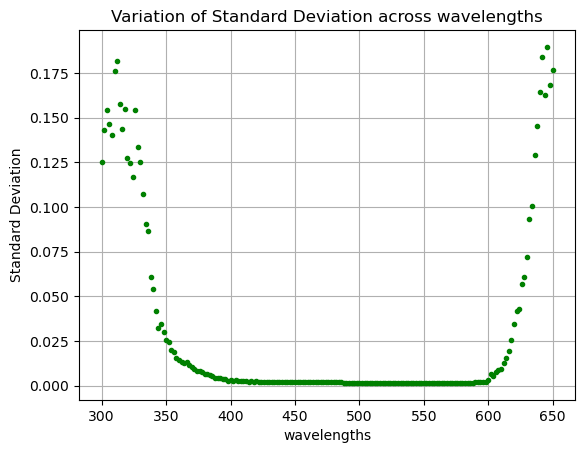

In [35]:
plt.plot(wavelengths, A_scaled.mean(axis=0),'.', color='green')
plt.title('Variation of Standard Deviation across wavelengths')
plt.xlabel('wavelengths')
plt.ylabel('Standard Deviation')
plt.grid()

In [29]:
L = np.diag(A_scaled.mean(axis=0))

In [30]:
Linv = np.linalg.inv(L)

In [31]:
rmse = []
for j in range(1,6) :
    RMSE = 0 
    for i in range(26) : 

        L = np.diag(np.append(A_scaled[:i], A_scaled[i+1:], axis=0).mean(axis=0))

        # LOOCV
        x = np.append(Am[:i], Am[i+1:], axis=0)   # modified Absorbance Matrix
        y = np.append(C[:i], C[i+1:], axis=0)   # modified Concentration Matrix 
        
        # Mean Shifting the data to perpare for PCA
        xs = (x - x.mean(axis=0))@np.linalg.inv(L)
        ys = y - y.mean(axis=0)

        # Performing SVD of Mean shifted Asborbance matrix : xs
        u, s, v = svd(xs/(N-1)**0.5, full_matrices=False)
        
        # Choosing the number of eigenvectors for Computing scores
        Nv = j 
        scores = xs@(v.T[:,0:Nv])
        B      = OLS_regression(scores, ys) # Computing regression Parameters Using OLS from mean shifted data

        # Error and RMSE Computation
        error = (Am[i]-x.mean(axis=0))@np.linalg.inv(L)@(v.T[:,0:Nv])@B + y.mean(axis=0) - C[i]
        RMSE += error@error.T

    RMSE = (RMSE/N)**0.5
    rmse.append(RMSE)

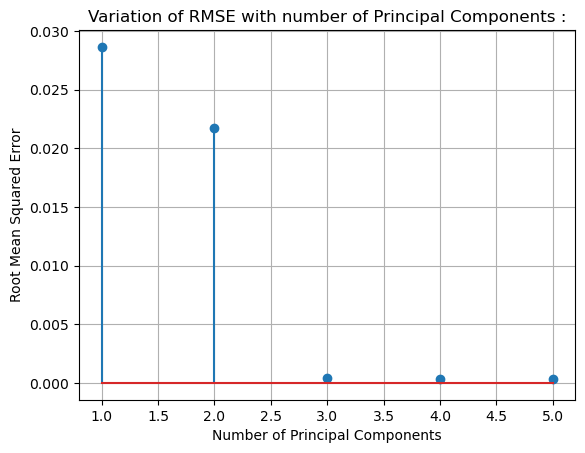

In [32]:
plt.stem([1,2,3,4,5], rmse)
plt.title("Variation of RMSE with number of Principal Components :")
plt.xlabel('Number of Principal Components')
plt.ylabel('Root Mean Squared Error')
plt.grid()